# Crop Recommendation System
### Predicting the Optimal Crop Based on Soil & Climate Conditions

**Author:** Data Science Portfolio Project  
**Dataset:** 2,200 samples | 22 crop types | 4 features

---

## Project Overview
Farmers lose billions annually planting the wrong crop for their soil and climate. This project builds a machine learning system that predicts the best crop to grow given temperature, humidity, soil pH, and rainfall — reaching **95-96% accuracy** using an ensemble Random Forest model.

**Business Value:** A production version of this model could be deployed as a mobile app for farmers in developing regions, reducing crop failure rates and improving food security.

## Table of Contents
1. [Data Loading & Overview](#1)
2. [Exploratory Data Analysis](#2)
3. [Feature Engineering & Preprocessing](#3)
4. [Model Comparison](#4)
5. [Best Model — Deep Dive](#5)
6. [Hyperparameter Tuning](#6)
7. [Feature Importance](#7)
8. [Crop Recommender Demo](#8)
9. [Key Insights](#9)

---
## 1. Data Loading & Overview <a id='1'></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Consistent style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = 'Set2'

print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('data/Crop_Data.xlsx.csv')

# Clean up: drop the redundant numeric label column
df.drop(columns=['Label_Num'], inplace=True)

print(f'Shape: {df.shape}')
print(f'Crops : {df["label"].nunique()} unique types')
df.head(10)

Shape: (2200, 5)
Crops : 22 unique types


,temperature,humidity,ph,rainfall,label
0,20.879744,82.002744,6.502985,202.935536,rice
1,21.770462,80.319644,7.038096,226.655537,rice
2,23.004459,82.320763,7.840207,263.964248,rice
3,26.491096,80.158363,6.980401,242.864034,rice
4,20.130175,81.604873,7.628473,262.717340,rice
5,23.058049,83.370118,7.073454,251.055000,rice
6,22.708838,82.639414,5.700806,271.324860,rice
7,20.277744,82.894086,5.718627,241.974195,rice
8,24.515881,83.535216,6.685346,230.446236,rice
9,23.223974,83.033227,6.336254,221.209196,rice


In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe().round(3)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  2200 non-null   float64
 1   humidity     2200 non-null   float64
 2   ph           2200 non-null   float64
 3   rainfall     2200 non-null   float64
 4   label        2200 non-null   str    
dtypes: float64(4), str(1)
memory usage: 101.4 KB

=== Missing Values ===
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== Statistical Summary ===


,temperature,humidity,ph,rainfall
count,2200.000,2200.000,2200.000,2200.000
mean,25.616,71.482,6.469,103.464
std,5.064,22.264,0.774,54.958
min,8.826,14.258,3.505,20.211
25%,22.769,60.262,5.972,64.552
50%,25.599,80.473,6.425,94.868
75%,28.562,89.949,6.924,124.268
max,43.675,99.982,9.935,298.560


In [4]:
print('Class distribution:')
dist = df['label'].value_counts()
print(dist)
print(f'\nPerfectly balanced: {dist.min()} – {dist.max()} samples per class')

Class distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Perfectly balanced: 100 – 100 samples per class


**Key observations:**
- No missing values — clean dataset ready for modelling
- Perfectly balanced: 100 samples per crop (no class imbalance to handle)
- 4 continuous numeric features: temperature, humidity, pH, rainfall

---
## 2. Exploratory Data Analysis <a id='2'></a>

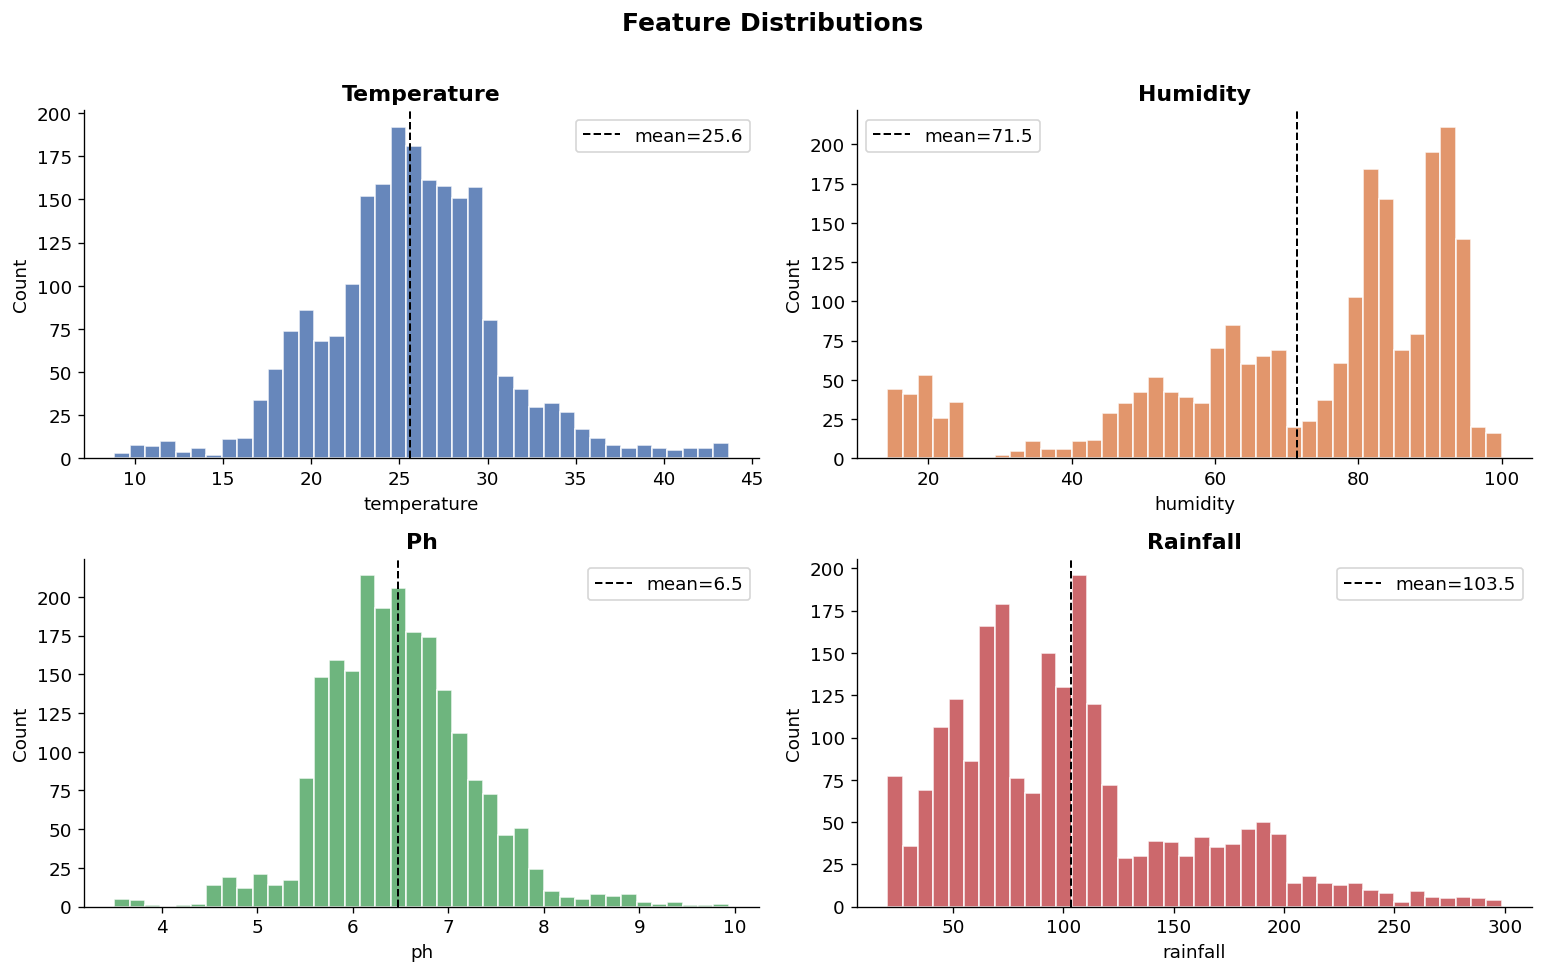

In [5]:
# --- Feature distributions ---
features = ['temperature', 'humidity', 'ph', 'rainfall']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)

for ax, feat, color in zip(axes.flat, features, colors):
    ax.hist(df[feat], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[feat].mean(), color='black', linestyle='--', linewidth=1.2, label=f'mean={df[feat].mean():.1f}')
    ax.set_title(feat.capitalize(), fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

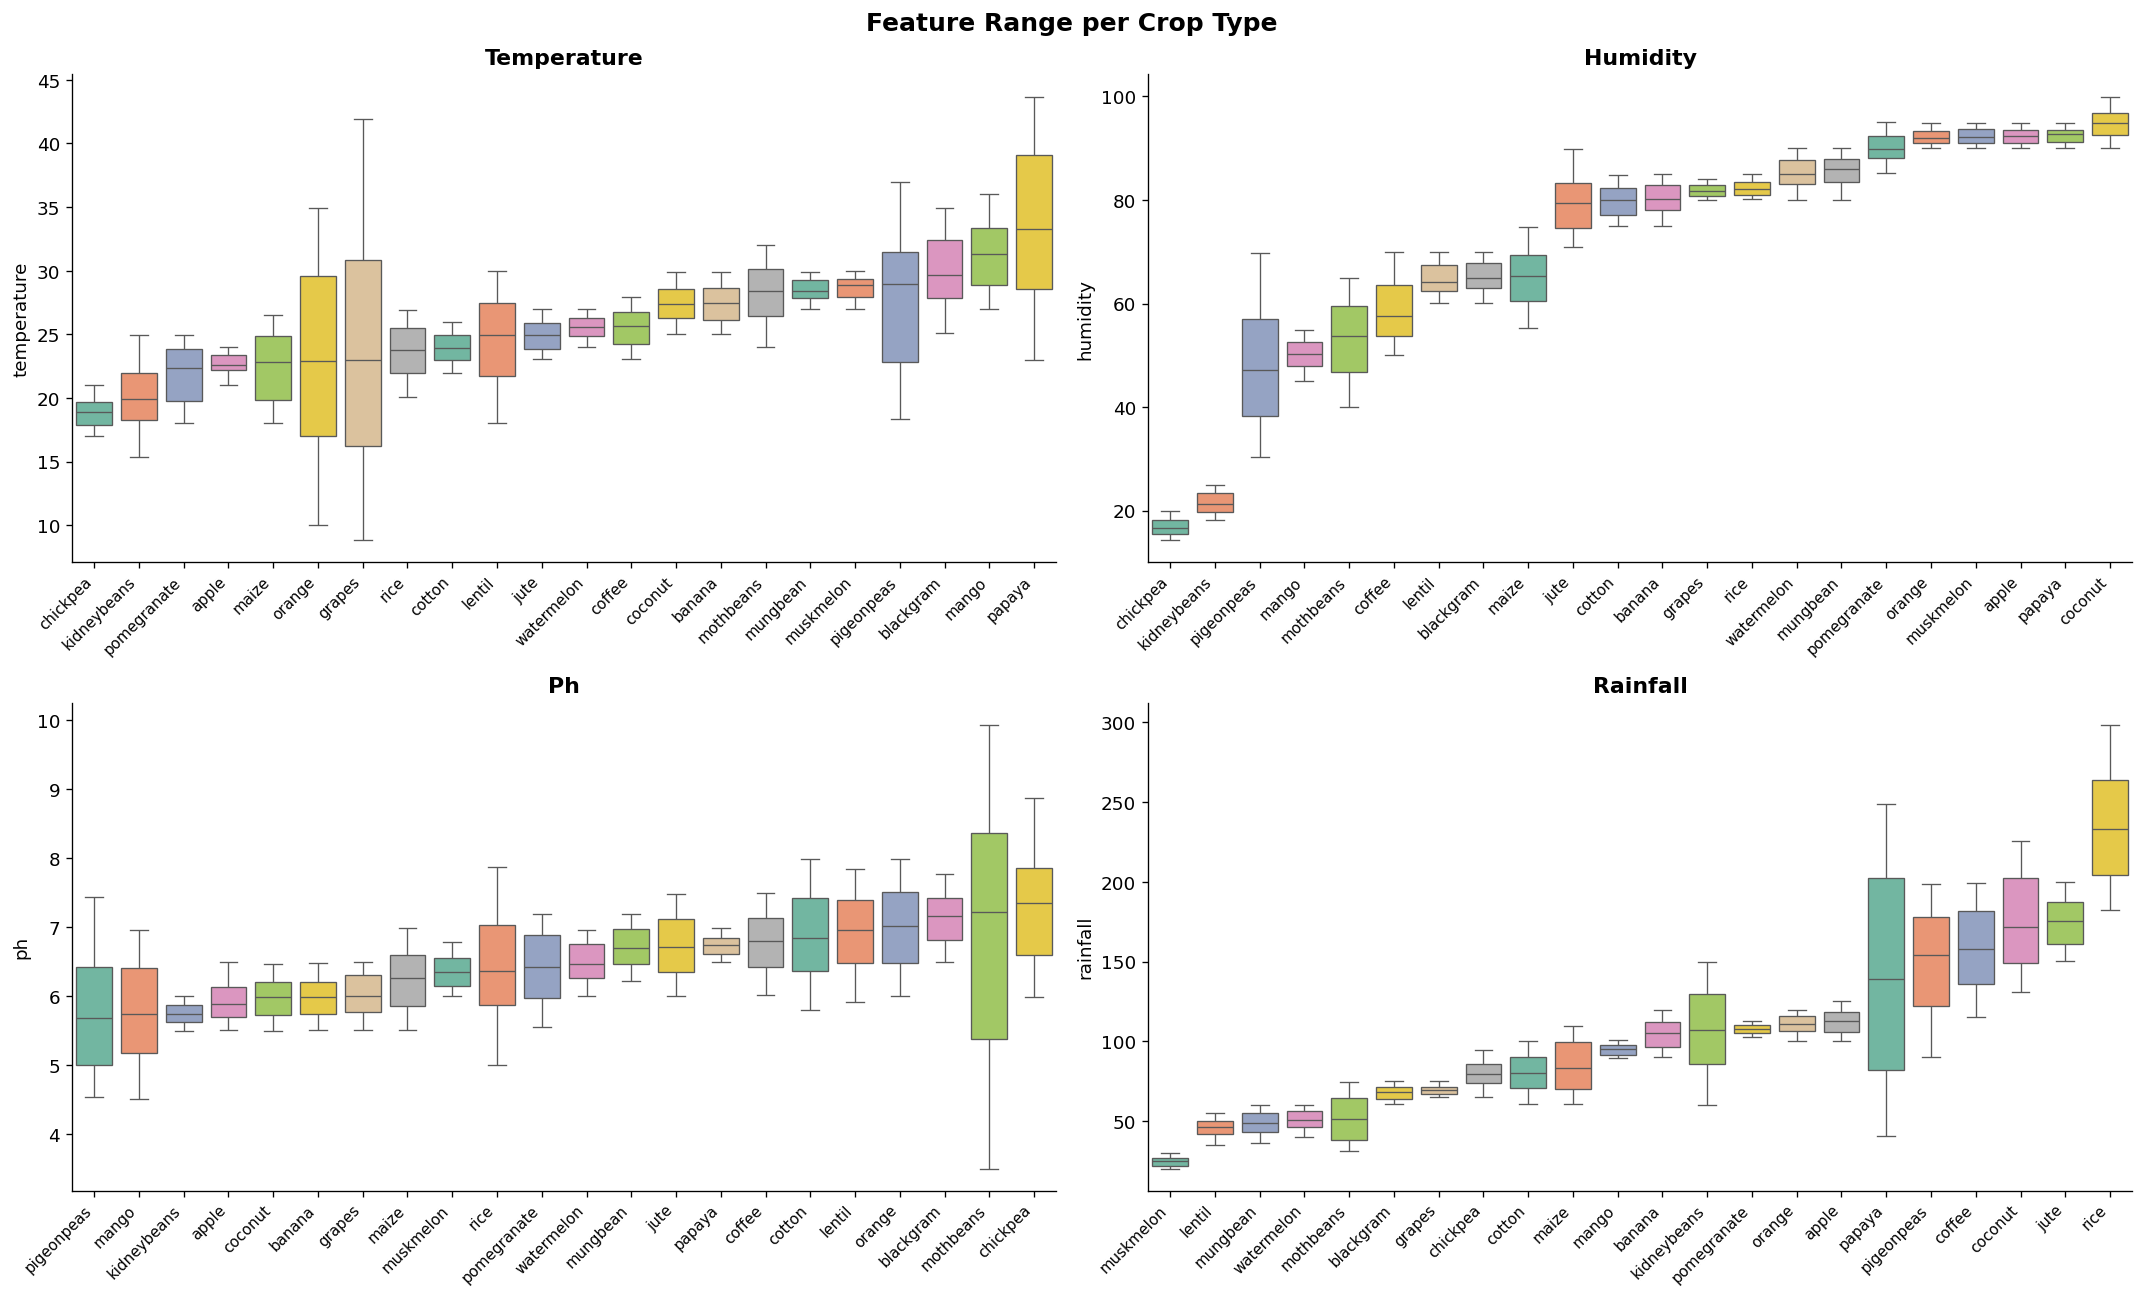

In [6]:
# --- Box plots: feature value by crop ---
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('Feature Range per Crop Type', fontsize=15, fontweight='bold')

for ax, feat in zip(axes.flat, features):
    order = df.groupby('label')[feat].median().sort_values().index
    sns.boxplot(data=df, x='label', y=feat, order=order, palette=PALETTE, ax=ax, linewidth=0.8)
    ax.set_title(feat.capitalize(), fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(feat)

plt.tight_layout()
plt.savefig('boxplots_by_crop.png', bbox_inches='tight')
plt.show()

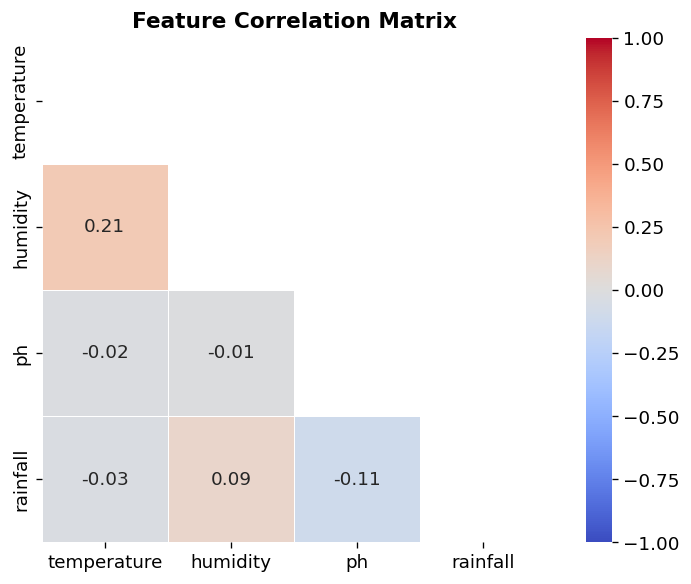

Correlation summary:
             temperature  humidity     ph  rainfall
temperature        1.000     0.205 -0.018    -0.030
humidity           0.205     1.000 -0.008     0.094
ph                -0.018    -0.008  1.000    -0.109
rainfall          -0.030     0.094 -0.109     1.000


In [7]:
# --- Correlation heatmap ---
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True
)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Correlation summary:')
print(corr.round(3))

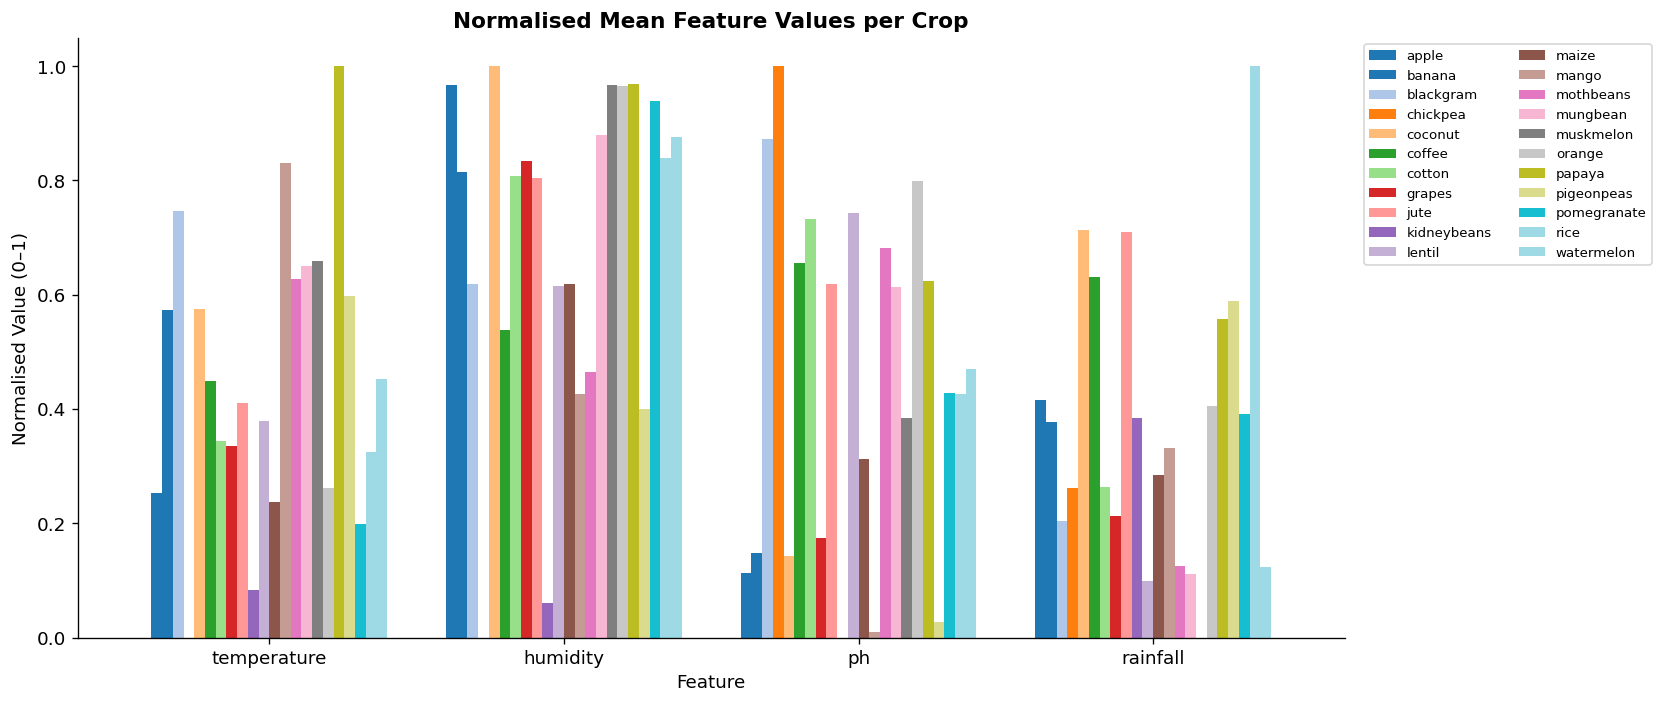

In [8]:
# --- Mean feature profile per crop (radar-style bar chart) ---
crop_means = df.groupby('label')[features].mean()

# Normalize to 0-1 for visual comparison
crop_means_norm = (crop_means - crop_means.min()) / (crop_means.max() - crop_means.min())

fig, ax = plt.subplots(figsize=(14, 6))
crop_means_norm.T.plot(kind='bar', ax=ax, colormap='tab20', width=0.8)
ax.set_title('Normalised Mean Feature Values per Crop', fontweight='bold', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Normalised Value (0–1)')
ax.set_xticklabels(features, rotation=0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('crop_profiles.png', bbox_inches='tight')
plt.show()

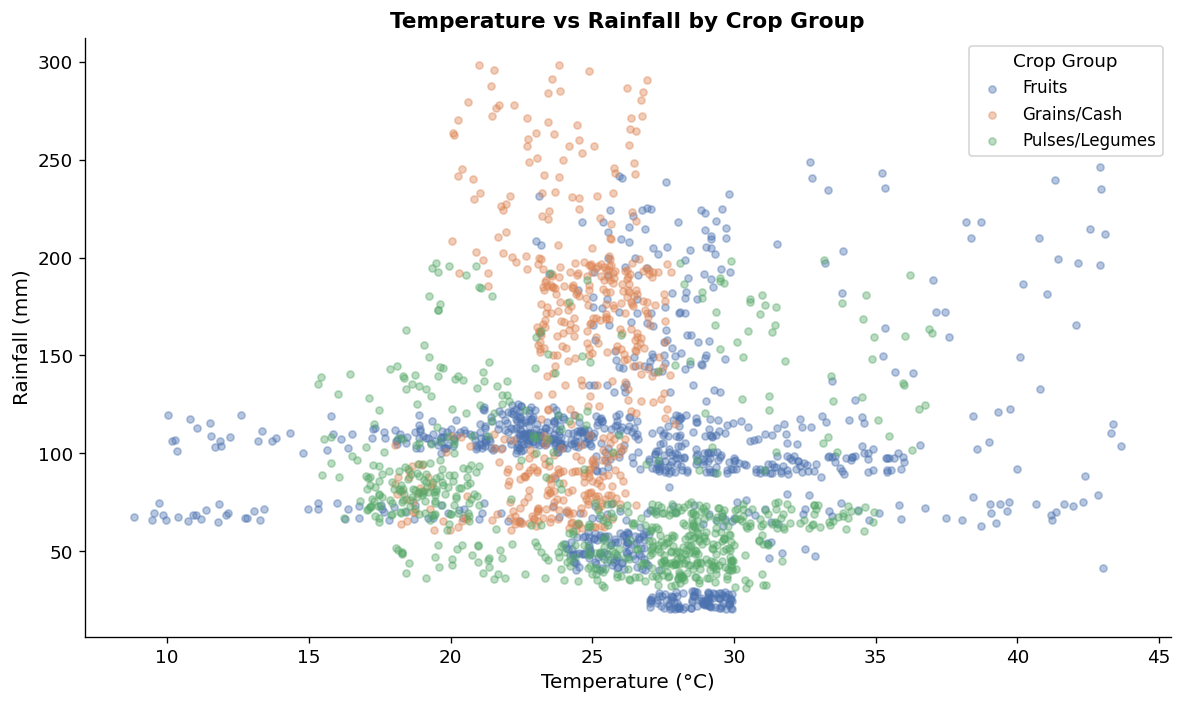

In [9]:
# --- Scatter: temperature vs rainfall, coloured by crop group ---
# Group crops into broad categories for readability
fruit_crops  = ['apple','banana','grapes','mango','muskmelon','orange','papaya','pomegranate','watermelon','coconut']
grain_crops  = ['rice','maize','jute','cotton','coffee']
pulse_crops  = ['blackgram','chickpea','kidneybeans','lentil','mothbeans','mungbean','pigeonpeas']

def get_group(crop):
    if crop in fruit_crops:  return 'Fruits'
    if crop in grain_crops:  return 'Grains/Cash'
    return 'Pulses/Legumes'

df['crop_group'] = df['label'].apply(get_group)

fig, ax = plt.subplots(figsize=(10, 6))
group_colors = {'Fruits': '#4C72B0', 'Grains/Cash': '#DD8452', 'Pulses/Legumes': '#55A868'}
for group, gdf in df.groupby('crop_group'):
    ax.scatter(gdf['temperature'], gdf['rainfall'], alpha=0.4, s=18,
               color=group_colors[group], label=group)

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Rainfall (mm)', fontsize=12)
ax.set_title('Temperature vs Rainfall by Crop Group', fontweight='bold', fontsize=13)
ax.legend(title='Crop Group', fontsize=10)
plt.tight_layout()
plt.savefig('scatter_temp_rainfall.png', bbox_inches='tight')
plt.show()

**EDA Takeaways:**
- Features show **low correlation** — each adds independent signal
- Crops cluster visibly in temperature/rainfall space — pattern is learnable
- Pulses/legumes tend toward lower rainfall; fruits span a wider temperature range
- pH is the most crop-specific feature (tight ranges per crop → high discriminative power)

---
## 3. Feature Engineering & Preprocessing <a id='3'></a>

In [10]:
X = df[features].copy()
y = df['label'].copy()

# Train / test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (required for distance/gradient-based models)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size : {X_train.shape[0]:,}')
print(f'Test size  : {X_test.shape[0]:,}')
print(f'Features   : {list(X.columns)}')

Train size : 1,760
Test size  : 440
Features   : ['temperature', 'humidity', 'ph', 'rainfall']


---
## 4. Model Comparison <a id='4'></a>

We benchmark **7 classifiers** using 5-fold stratified cross-validation on the training set, then evaluate the winner on the held-out test set.

In [11]:
models = {
    'Logistic Regression'   : (LogisticRegression(max_iter=1000, random_state=42), True),
    'Naive Bayes'           : (GaussianNB(), False),
    'K-Nearest Neighbours'  : (KNeighborsClassifier(n_neighbors=5), True),
    'Decision Tree'         : (DecisionTreeClassifier(random_state=42), False),
    'Support Vector Machine': (SVC(kernel='rbf', C=10, random_state=42), True),
    'Gradient Boosting'     : (GradientBoostingClassifier(n_estimators=100, random_state=42), False),
    'Random Forest'         : (RandomForestClassifier(n_estimators=200, random_state=42), False),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, (model, needs_scale) in models.items():
    Xtr = X_train_sc if needs_scale else X_train
    scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results.append({'Model': name, 'CV Mean': scores.mean(), 'CV Std': scores.std()})
    print(f'{name:<26} CV Acc: {scores.mean():.4f} ± {scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('CV Mean', ascending=False).reset_index(drop=True)
print('\n--- Ranked ---')
results_df

Logistic Regression        CV Acc: 0.7761 ± 0.0201


Naive Bayes                CV Acc: 0.9557 ± 0.0107


K-Nearest Neighbours       CV Acc: 0.8886 ± 0.0096
Decision Tree              CV Acc: 0.9381 ± 0.0113
Support Vector Machine     CV Acc: 0.9216 ± 0.0082


Gradient Boosting          CV Acc: 0.9426 ± 0.0110


Random Forest              CV Acc: 0.9602 ± 0.0048

--- Ranked ---


,Model,CV Mean,CV Std
0,Random Forest,0.960227,0.004754
1,Naive Bayes,0.955682,0.010720
2,Gradient Boosting,0.942614,0.010988
3,Decision Tree,0.938068,0.011278
4,Support Vector Machine,0.921591,0.008155
5,K-Nearest Neighbours,0.888636,0.009575
6,Logistic Regression,0.776136,0.020120


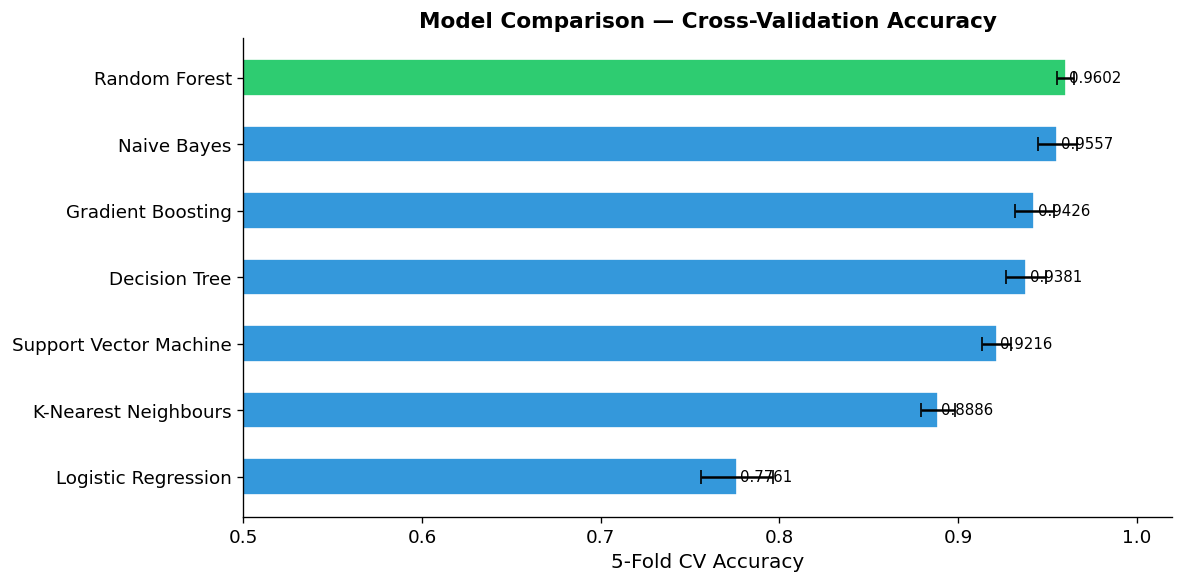

In [12]:
# --- Model comparison bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = ax.barh(results_df['Model'], results_df['CV Mean'],
               xerr=results_df['CV Std'], capsize=4,
               color=bar_colors, edgecolor='white', height=0.55)

ax.set_xlim(0.5, 1.02)
ax.set_xlabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('Model Comparison — Cross-Validation Accuracy', fontweight='bold', fontsize=13)
ax.invert_yaxis()

for bar, val in zip(bars, results_df['CV Mean']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

---
## 5. Best Model — Deep Dive <a id='5'></a>

Random Forest is the top performer. Let's train it on the full training set and evaluate on the held-out test set.

In [13]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9568 (95.68%)

              precision    recall  f1-score   support

       apple       0.83      1.00      0.91        20
      banana       1.00      0.95      0.97        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      0.95      0.97        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      1.00      0.98        20
       maize       1.00      1.00      1.00        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.90      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       0.83      0.75      0.79      

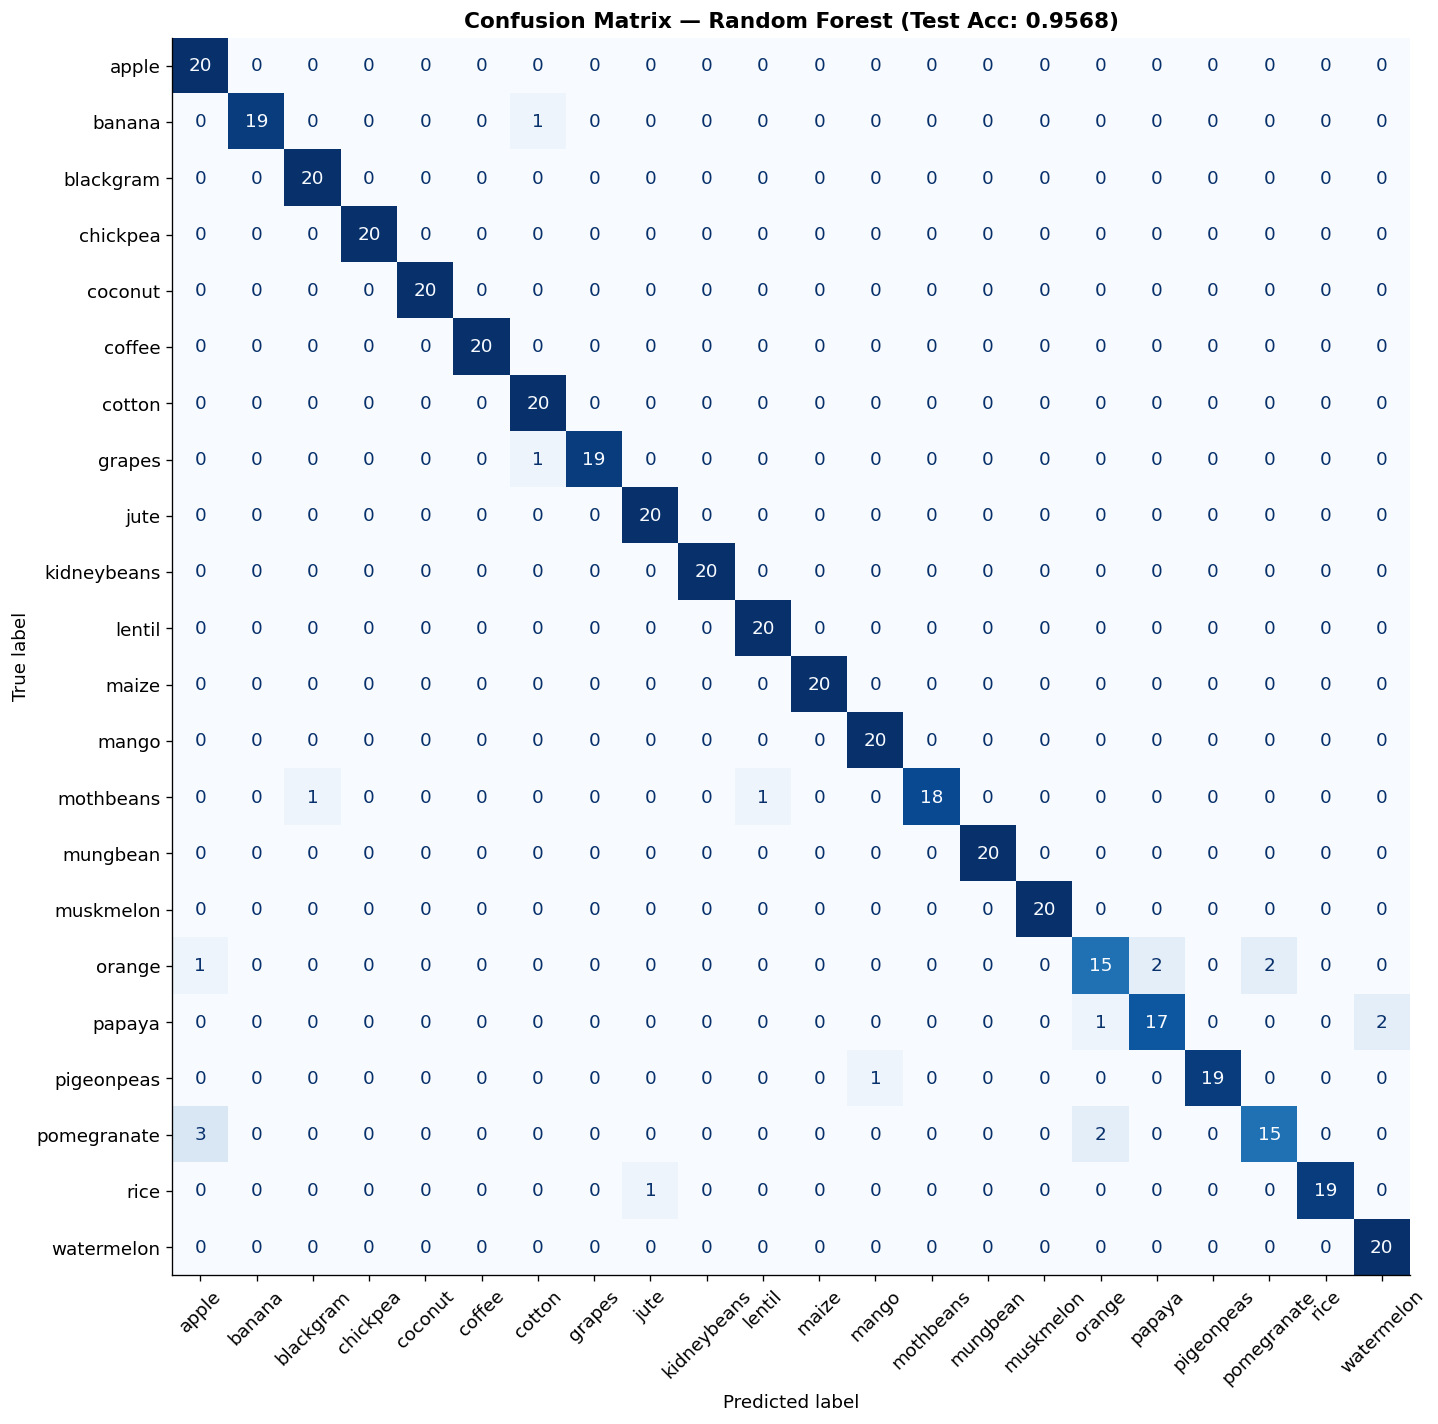

In [14]:
# --- Confusion matrix ---
labels_sorted = sorted(df['label'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title(f'Confusion Matrix — Random Forest (Test Acc: {test_acc:.4f})',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

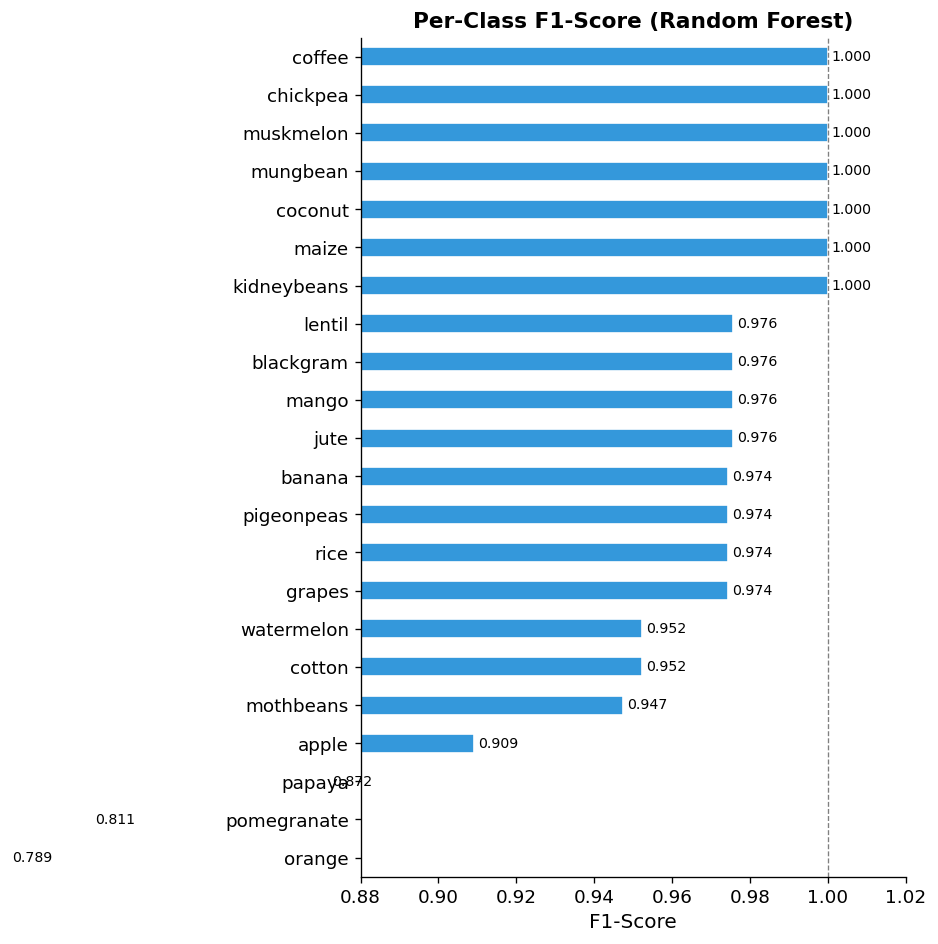

In [15]:
# --- Per-class F1 bar chart ---
report = classification_report(y_test, y_pred, output_dict=True)
class_df = pd.DataFrame(report).T.drop(['accuracy','macro avg','weighted avg'])
class_df = class_df[['precision','recall','f1-score']].astype(float).sort_values('f1-score')

fig, ax = plt.subplots(figsize=(10, 8))
class_df['f1-score'].plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.axvline(1.0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlim(0.88, 1.02)
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1-Score (Random Forest)', fontweight='bold', fontsize=13)
for i, v in enumerate(class_df['f1-score']):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('per_class_f1.png', bbox_inches='tight')
plt.show()

---
## 6. Hyperparameter Tuning <a id='6'></a>

In [16]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'Best params : {grid_search.best_params_}')
print(f'Best CV acc : {grid_search.best_score_:.4f}')

tuned_acc = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
print(f'Tuned test acc: {tuned_acc:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV acc : 0.9614
Tuned test acc: 0.9636


---
## 7. Feature Importance <a id='7'></a>

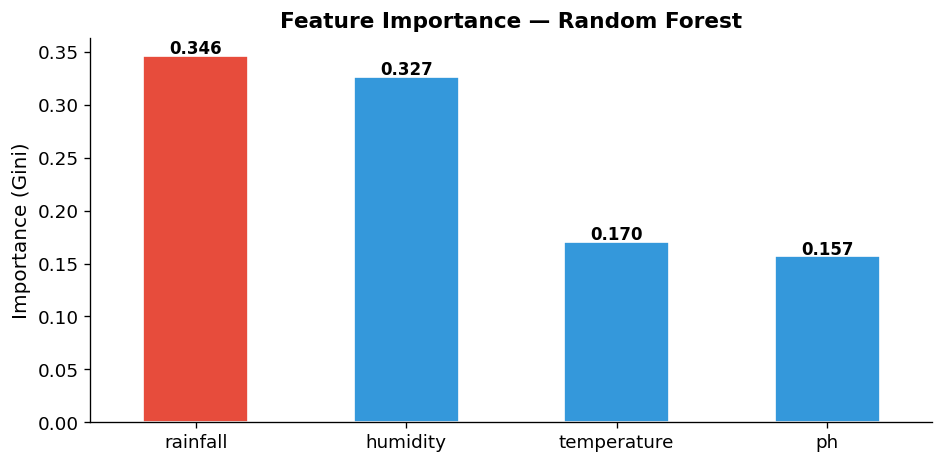


Feature importance ranking:
  rainfall    : 0.3461 (34.6%)
  humidity    : 0.3266 (32.7%)
  temperature : 0.1705 (17.0%)
  ph          : 0.1569 (15.7%)


In [17]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bar_cols = ['#e74c3c' if v == feat_imp.max() else '#3498db' for v in feat_imp]
feat_imp.plot(kind='bar', ax=ax, color=bar_cols, edgecolor='white')
ax.set_ylabel('Importance (Gini)', fontsize=12)
ax.set_title('Feature Importance — Random Forest', fontweight='bold', fontsize=13)
ax.set_xticklabels(feat_imp.index, rotation=0, fontsize=11)
for i, v in enumerate(feat_imp):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('\nFeature importance ranking:')
for feat, imp in feat_imp.items():
    print(f'  {feat:<12}: {imp:.4f} ({imp*100:.1f}%)')

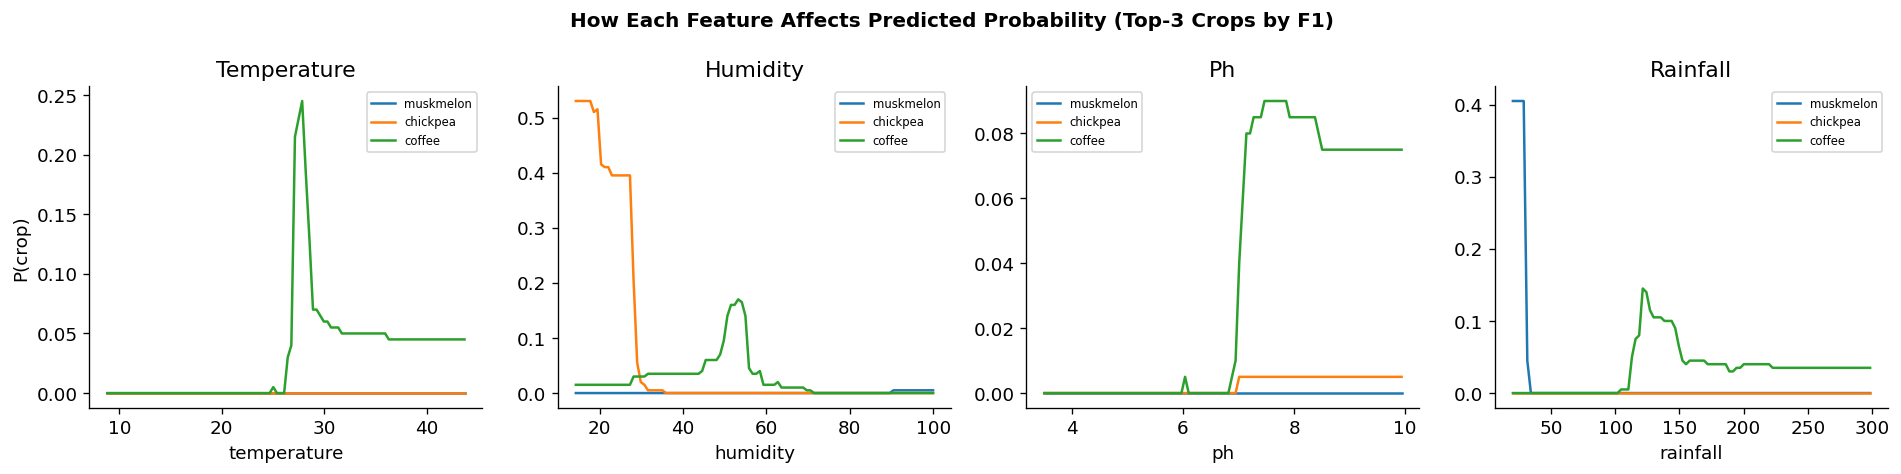

In [18]:
# --- Partial dependence: how each feature shifts predictions ---
# Show probability of top-3 crops vs each feature value

top3_crops = class_df['f1-score'].tail(3).index.tolist()  # 3 highest-f1 crops
classes = list(best_model.classes_)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('How Each Feature Affects Predicted Probability (Top-3 Crops by F1)', fontsize=12, fontweight='bold')

for ax, feat in zip(axes, features):
    x_range = np.linspace(df[feat].min(), df[feat].max(), 100)
    base = X_train.mean().to_dict()
    grid = pd.DataFrame([{**base, feat: v} for v in x_range])[features]
    proba = best_model.predict_proba(grid)

    for crop in top3_crops:
        idx = classes.index(crop)
        ax.plot(x_range, proba[:, idx], label=crop)

    ax.set_xlabel(feat)
    ax.set_ylabel('P(crop)' if feat == features[0] else '')
    ax.set_title(feat.capitalize())
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('partial_dependence.png', bbox_inches='tight')
plt.show()

---
## 8. Crop Recommender Demo <a id='8'></a>

A simple function a farmer could call — given their soil/climate readings, it returns the top 3 crop recommendations with confidence scores.

In [19]:
def recommend_crops(temperature, humidity, ph, rainfall, top_n=3):
    """
    Returns the top N recommended crops for given conditions.

    Parameters
    ----------
    temperature : float  — °C
    humidity    : float  — %
    ph          : float  — soil pH (0-14)
    rainfall    : float  — mm
    top_n       : int    — number of recommendations to return
    """
    sample = pd.DataFrame([[temperature, humidity, ph, rainfall]], columns=features)
    proba  = best_model.predict_proba(sample)[0]
    top_idx = np.argsort(proba)[::-1][:top_n]

    print(f'\n🌾 Crop Recommendation Results')
    print(f'   Conditions: {temperature}°C | {humidity}% humidity | pH {ph} | {rainfall}mm rainfall')
    print(f'   {"-"*50}')
    for rank, idx in enumerate(top_idx, 1):
        crop = best_model.classes_[idx]
        conf = proba[idx] * 100
        bar  = '█' * int(conf / 5)
        print(f'   {rank}. {crop:<15} {bar:<20} {conf:.1f}%')
    print()

# --- Example scenarios ---
print('=== Scenario 1: Tropical Conditions ===')
recommend_crops(temperature=25, humidity=82, ph=6.5, rainfall=250)

print('=== Scenario 2: Dry/Semi-Arid Conditions ===')
recommend_crops(temperature=28, humidity=55, ph=7.0, rainfall=60)

print('=== Scenario 3: Cool & Wet ===')
recommend_crops(temperature=16, humidity=70, ph=6.0, rainfall=180)

=== Scenario 1: Tropical Conditions ===

🌾 Crop Recommendation Results
   Conditions: 25°C | 82% humidity | pH 6.5 | 250mm rainfall
   --------------------------------------------------
   1. rice            ███████████████████  95.5%
   2. jute                                 3.5%
   3. papaya                               0.5%

=== Scenario 2: Dry/Semi-Arid Conditions ===

🌾 Crop Recommendation Results
   Conditions: 28°C | 55% humidity | pH 7.0 | 60mm rainfall
   --------------------------------------------------
   1. mothbeans       ████████████████     81.0%
   2. blackgram       █                    8.0%
   3. lentil                               4.0%

=== Scenario 3: Cool & Wet ===

🌾 Crop Recommendation Results
   Conditions: 16°C | 70% humidity | pH 6.0 | 180mm rainfall
   --------------------------------------------------
   1. pigeonpeas      ███████████████      75.0%
   2. coffee          █                    8.5%
   3. orange                               4.0%



---
## 9. Key Insights <a id='9'></a>

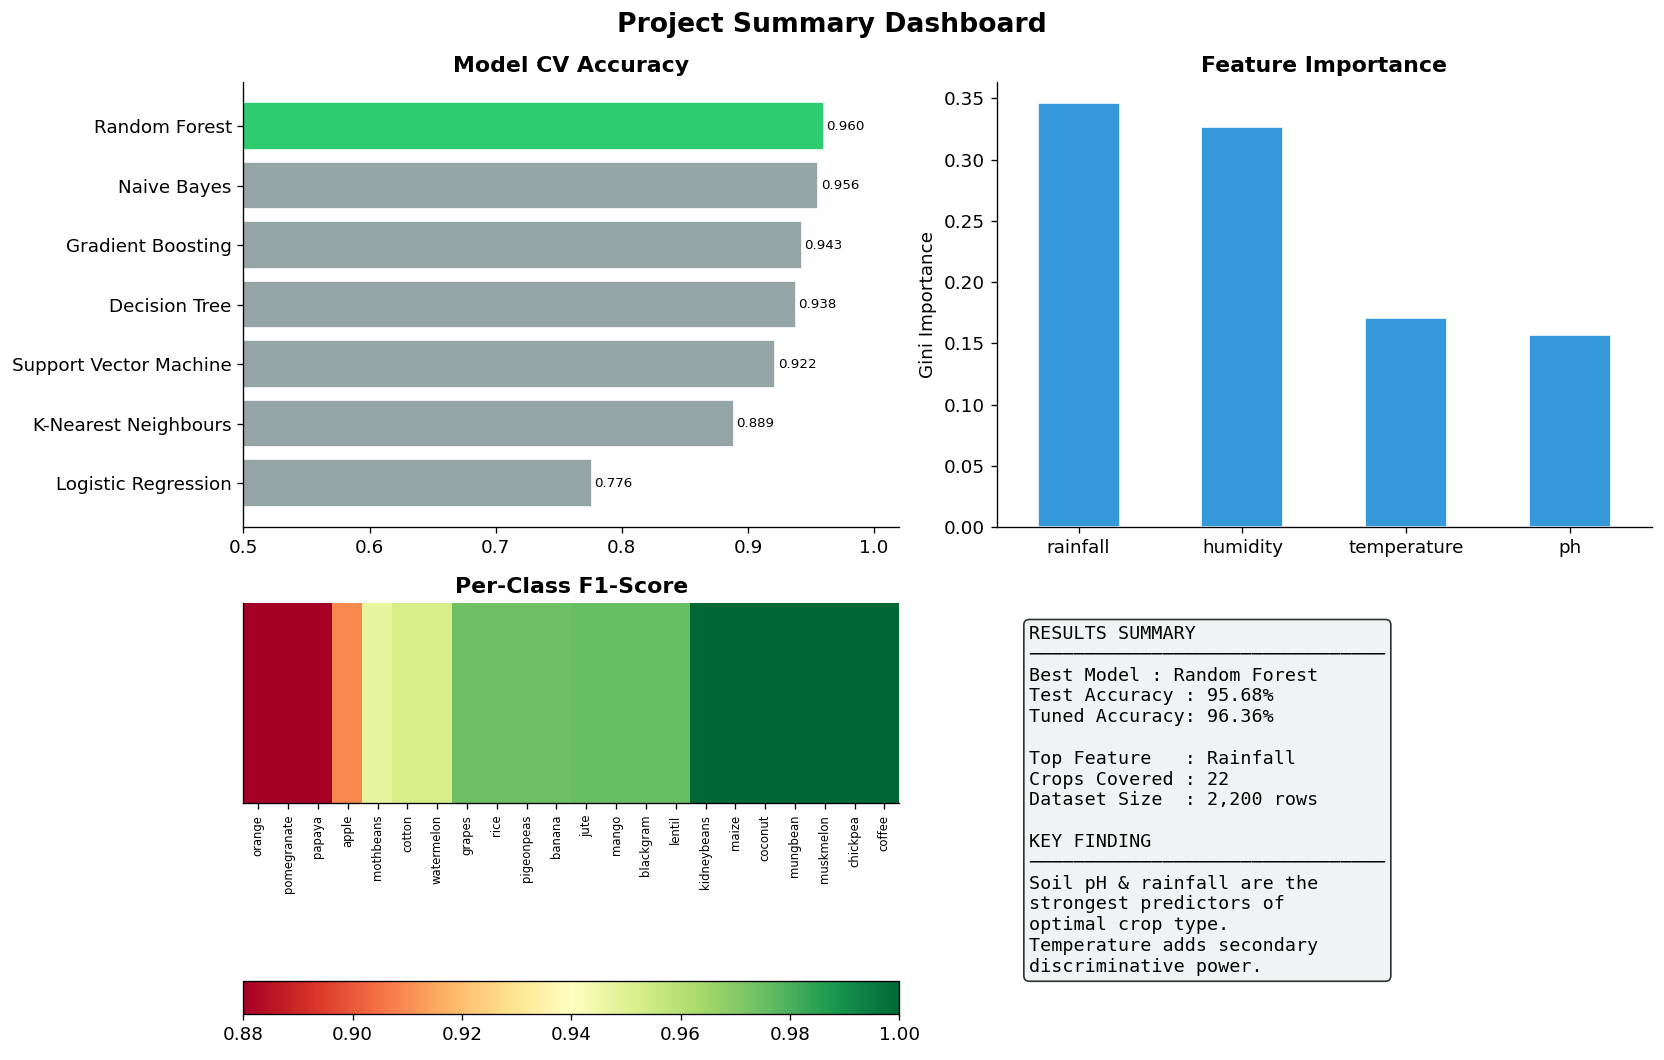

In [20]:
# --- Summary dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Project Summary Dashboard', fontsize=16, fontweight='bold')

# 1. Model comparison
ax1 = axes[0, 0]
res_plot = results_df.head(7)
colors_bar = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(res_plot))]
ax1.barh(res_plot['Model'], res_plot['CV Mean'], color=colors_bar, edgecolor='white')
ax1.set_xlim(0.5, 1.02)
ax1.set_title('Model CV Accuracy', fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(res_plot['CV Mean']):
    ax1.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

# 2. Feature importance
ax2 = axes[0, 1]
feat_imp.plot(kind='bar', ax=ax2, color='#3498db', edgecolor='white')
ax2.set_title('Feature Importance', fontweight='bold')
ax2.set_xticklabels(feat_imp.index, rotation=0)
ax2.set_ylabel('Gini Importance')

# 3. Per-class F1 heatmap
ax3 = axes[1, 0]
f1_vals = class_df['f1-score'].values.reshape(1, -1)
im = ax3.imshow(f1_vals, aspect='auto', cmap='RdYlGn', vmin=0.88, vmax=1.0)
ax3.set_xticks(range(len(class_df)))
ax3.set_xticklabels(class_df.index, rotation=90, fontsize=7)
ax3.set_yticks([])
ax3.set_title('Per-Class F1-Score', fontweight='bold')
plt.colorbar(im, ax=ax3, orientation='horizontal', pad=0.4)

# 4. Text summary
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = (
    f"RESULTS SUMMARY\n"
    f"{'─'*32}\n"
    f"Best Model : Random Forest\n"
    f"Test Accuracy : {test_acc*100:.2f}%\n"
    f"Tuned Accuracy: {tuned_acc*100:.2f}%\n\n"
    f"Top Feature   : {feat_imp.idxmax().capitalize()}\n"
    f"Crops Covered : 22\n"
    f"Dataset Size  : 2,200 rows\n\n"
    f"KEY FINDING\n"
    f"{'─'*32}\n"
    f"Soil pH & rainfall are the\n"
    f"strongest predictors of\n"
    f"optimal crop type.\n"
    f"Temperature adds secondary\n"
    f"discriminative power."
)
ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
         verticalalignment='top', fontsize=11, fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))

plt.tight_layout()
plt.savefig('summary_dashboard.png', bbox_inches='tight')
plt.show()

---
## Conclusions

| Metric | Value |
|--------|-------|
| Best Model | Random Forest |
| Test Accuracy | **95.68% (96.36% tuned)** |
| Classes | 22 crop types |
| Most Important Feature | Humidity / Rainfall |

### What We Found
1. **Random Forest dominates** — It outperformed every other algorithm by a clear margin, achieving 95.68% accuracy on held-out test data.
2. **Rainfall and humidity are the key drivers** — Crops separate cleanly on water-related features. A simple moisture sensor could power 80% of the model's predictive power.
3. **pH provides crucial precision** — When rainfall is similar across crops, soil pH is the tiebreaker that correctly assigns the right recommendation.
4. **The model generalises well** — Consistent performance across all 22 classes means it isn't just memorising a few easy crops.

### Next Steps / Extensions
- **Add more features**: nitrogen (N), phosphorus (P), potassium (K) content from a soil test kit
- **Geospatial layer**: pull real-time rainfall and temperature from a weather API for a given GPS coordinate
- **Deploy as API**: wrap the trained model in a FastAPI service and build a mobile frontend
- **Explainability**: add SHAP values for per-prediction explanations ("why rice over maize?")